# Media Sentiment and Food Price Inflation in Germany

## Research Question
How is media sentiment toward food price inflation reflected in recent news coverage in Germany, and how does it relate to food price developments?

## Why this question matters
Rising food prices affect households directly and often receive strong media attention.
This notebook examines whether media sentiment became more negative when food prices increased.

## Data Sources
- Eurostat HICP monthly index for Germany:
  - Milk, cheese and eggs
  - Butter
- News API dataset:
  - Article title
  - Description
  - Content
  - Publication date

## Use of AI Tools

ChatGPT was used to support the development of this notebook. This includes assistance in refining the structure of the analysis, improving selected helper functions, and suggesting suitable visualization approaches.

All code and results were reviewed, adapted where necessary, and validated independently.

In [19]:
import json
from pathlib import Path
import re

import matplotlib.pyplot as plt
import pandas as pd
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

In [20]:
# Define file paths for all input datasets used in the analysis.
DATA_DIR = Path(".")
NEWS_FILE = DATA_DIR / "news_data.json"
DAIRY_FILE = DATA_DIR / "eurostat_cpi_dairy.json"
BUTTER_FILE = DATA_DIR / "eurostat_butter_cpi.json"

In [21]:
NEWS_FILE = DATA_DIR / "news_data.json"
# Load the news dataset and remove the invalid API prefix before parsing the JSON content.
with open(NEWS_FILE, "r", encoding="utf-8") as file:
    text = file.read()

text = text.replace("news api:", "")
news_data_json = json.loads(text)

news = pd.DataFrame(news_data_json["articles"])

In [22]:
print(len(news_data_json["articles"]))
pd.DataFrame(news_data_json["articles"]).head()

58


,source,author,title,description,url,urlToImage,publishedAt,content
0,"{'id': None, 'name': 'Noe.orf.at'}",ORF.at,Koch-Lehrlinge als Zukunftshoffnung für Gastro,Zahlreiche der landesweit 8.000 Gastrobetriebe...,https://noe.orf.at/stories/3343578/,https://ibs.orf.at/noe?image=https%3A%2F%2Foek...,2026-03-01T12:10:23Z,"Personalmangel, hohe Inflation, gestiegene Ene..."
1,"{'id': 'die-zeit', 'name': 'Die Zeit'}",DIE ZEIT: News -,Verbraucherpreise: Energie günstiger: Inflatio...,Hier finden Sie Informationen zu dem Thema „Ve...,https://www.zeit.de/news/2026-02/27/energie-gu...,https://img.zeit.de/news/2026-02/27/energie-gu...,2026-02-27T13:18:26Z,Kaum noch Preisanstiege bei Lebensmitteln und ...
2,"{'id': None, 'name': 'STERN.de'}",STERN.de,Verbraucherpreise: Energie günstiger: Inflatio...,"Lebensmittel, Heizen, Restaurantbesuche: Das L...",https://www.stern.de/news/verbraucherpreise--e...,https://image.stern.de/37177240/t/jJ/v1/w1440/...,2026-02-27T13:18:26Z,Kopiere den aktuellen Link\r\nZur Merkliste hi...
3,"{'id': None, 'name': 'STERN.de'}",STERN.de,Löhne: Mehr Kaufkraft für Arbeitnehmer – Reall...,Wiesbaden (lhe) - Hessens Arbeitnehmer haben i...,https://www.stern.de/gesellschaft/regional/hes...,https://image.stern.de/37177216/t/OL/v1/w1440/...,2026-02-27T13:08:04Z,Kopiere den aktuellen Link\r\nZur Merkliste hi...
4,"{'id': 'die-zeit', 'name': 'Die Zeit'}",DIE ZEIT: News -,Löhne: Mehr Kaufkraft für Arbeitnehmer – Reall...,Hier finden Sie Informationen zu dem Thema „Lö...,https://www.zeit.de/news/2026-02/27/mehr-kaufk...,https://img.zeit.de/news/2026-02/27/mehr-kaufk...,2026-02-27T13:08:04Z,Hessens Arbeitnehmer haben im vergangenen Jahr...


In [23]:
print(news.shape)
news.head()

(58, 8)


,source,author,title,description,url,urlToImage,publishedAt,content
0,"{'id': None, 'name': 'Noe.orf.at'}",ORF.at,Koch-Lehrlinge als Zukunftshoffnung für Gastro,Zahlreiche der landesweit 8.000 Gastrobetriebe...,https://noe.orf.at/stories/3343578/,https://ibs.orf.at/noe?image=https%3A%2F%2Foek...,2026-03-01T12:10:23Z,"Personalmangel, hohe Inflation, gestiegene Ene..."
1,"{'id': 'die-zeit', 'name': 'Die Zeit'}",DIE ZEIT: News -,Verbraucherpreise: Energie günstiger: Inflatio...,Hier finden Sie Informationen zu dem Thema „Ve...,https://www.zeit.de/news/2026-02/27/energie-gu...,https://img.zeit.de/news/2026-02/27/energie-gu...,2026-02-27T13:18:26Z,Kaum noch Preisanstiege bei Lebensmitteln und ...
2,"{'id': None, 'name': 'STERN.de'}",STERN.de,Verbraucherpreise: Energie günstiger: Inflatio...,"Lebensmittel, Heizen, Restaurantbesuche: Das L...",https://www.stern.de/news/verbraucherpreise--e...,https://image.stern.de/37177240/t/jJ/v1/w1440/...,2026-02-27T13:18:26Z,Kopiere den aktuellen Link\r\nZur Merkliste hi...
3,"{'id': None, 'name': 'STERN.de'}",STERN.de,Löhne: Mehr Kaufkraft für Arbeitnehmer – Reall...,Wiesbaden (lhe) - Hessens Arbeitnehmer haben i...,https://www.stern.de/gesellschaft/regional/hes...,https://image.stern.de/37177216/t/OL/v1/w1440/...,2026-02-27T13:08:04Z,Kopiere den aktuellen Link\r\nZur Merkliste hi...
4,"{'id': 'die-zeit', 'name': 'Die Zeit'}",DIE ZEIT: News -,Löhne: Mehr Kaufkraft für Arbeitnehmer – Reall...,Hier finden Sie Informationen zu dem Thema „Lö...,https://www.zeit.de/news/2026-02/27/mehr-kaufk...,https://img.zeit.de/news/2026-02/27/mehr-kaufk...,2026-02-27T13:08:04Z,Hessens Arbeitnehmer haben im vergangenen Jahr...


In [24]:
# LLM-assisted code section:
# This helper function was developed with LLM support and reviewed manually.
def eurostat_to_df(data, value_column):
    """Convert Eurostat JSON into a tidy monthly DataFrame."""
    time_index = data["dimension"]["time"]["category"]["index"]
    time_labels = data["dimension"]["time"]["category"]["label"]
    values = data["value"]

    rows = []

    for key, position in time_index.items():
        position_key = str(position)

        if position_key in values:
            rows.append(
                {
                    "date": pd.to_datetime(time_labels[key], format="%Y-%m"),
                    value_column: values[position_key],
                }
            )

    df = pd.DataFrame(rows)
    return df.sort_values("date").reset_index(drop=True)

In [25]:
def z_score(series):
    """Standardize a pandas Series."""
    return (series - series.mean()) / series.std()

In [26]:
# LLM-assisted code section:
# This preprocessing function was developed with LLM support and adapted manually.

# Combine title, description, and content into one text field for filtering and sentiment analysis.
def prepare_news_text(df):
    """Combine text fields into one analysis column."""
    text = (
        df["title"].fillna("") + ". " +
        df["description"].fillna("") + ". " +
        df["content"].fillna("")
    )

    return text.str.strip()

In [27]:
# Load the Eurostat CPI datasets for dairy products and butter.
with open(DAIRY_FILE, "r", encoding="utf-8") as file:
    dairy_json = json.load(file)

with open(BUTTER_FILE, "r", encoding="utf-8") as file:
    butter_json = json.load(file)

In [28]:
# Convert both Eurostat datasets into tidy monthly DataFrames.
dairy = eurostat_to_df(dairy_json, "dairy_cpi")
butter = eurostat_to_df(butter_json, "butter_cpi")

In [29]:
# Restrict both CPI series to the analysis period from January 2023 to December 2024.
start_date = "2023-01-01"
end_date = "2025-01-01"

dairy = dairy[(dairy["date"] >= start_date) & (dairy["date"] < end_date)].copy()
butter = butter[(butter["date"] >= start_date) & (butter["date"] < end_date)].copy()

In [30]:
dairy["dairy_pct_change"] = dairy["dairy_cpi"].pct_change() * 100
dairy["price_increase"] = dairy["dairy_pct_change"] > 0

butter["butter_pct_change"] = butter["butter_cpi"].pct_change() * 100

In [31]:
dairy.head()

,date,dairy_cpi,dairy_pct_change,price_increase
324,2023-01-01,162.5,NaN,False
325,2023-02-01,163.6,0.676923,True
326,2023-03-01,164.2,0.366748,True
327,2023-04-01,164.4,0.121803,True
328,2023-05-01,163.0,-0.851582,False


In [32]:
butter.head()

,date,butter_cpi,butter_pct_change
97,2023-01-01,213.0,NaN
98,2023-02-01,182.5,-14.319249
99,2023-03-01,169.8,-6.958904
100,2023-04-01,163.7,-3.592462
101,2023-05-01,161.5,-1.343922


In [33]:
news = news[["title", "description", "content", "publishedAt"]].copy()

In [34]:
news["publishedAt"] = pd.to_datetime(news["publishedAt"], errors="coerce")
news = news.dropna(subset=["publishedAt", "title"]).copy()

In [35]:
news["month"] = news["publishedAt"].dt.to_period("M").dt.to_timestamp()
news["text"] = prepare_news_text(news)

/var/folders/kw/zc7qtxtd0j5dyfl27njttk200000gn/T/ipykernel_74360/931061332.py:1: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  news["month"] = news["publishedAt"].dt.to_period("M").dt.to_timestamp()


In [36]:
# Define keywords used to identify articles related to food prices and inflation.
keywords = [
    "food",
    "food price",
    "food prices",
    "food inflation",
    "inflation",
    "preise",
    "preis",
    "verbraucherpreise",
    "lebensmittel",
    "lebensmittelpreise",
    "butter",
    "dairy",
    "milchprodukte",
    "butterpreis",
    "teuer"
]

In [37]:
# Keep only articles that mention food-price-related keywords.
pattern = "|".join(re.escape(keyword) for keyword in keywords)

news_filtered = news[
    news["text"].str.contains(pattern, case=False, na=False, regex=True)
].copy()

In [38]:
news[["title"]].head(20)

,title
0,Koch-Lehrlinge als Zukunftshoffnung für Gastro
1,Verbraucherpreise: Energie günstiger: Inflatio...
2,Verbraucherpreise: Energie günstiger: Inflatio...
3,Löhne: Mehr Kaufkraft für Arbeitnehmer – Reall...
4,Löhne: Mehr Kaufkraft für Arbeitnehmer – Reall...
5,Verbraucherpreise: Energie günstiger: Inflatio...
6,Verbraucherpreise: Inflation sinkt im Februar ...
7,Wirtschaftslage: Reallöhne sind 2025 erneut ge...
8,Reallöhne: Deutsche Reallöhne sind 2025 erneut...
9,Reallöhne: Deutsche Reallöhne sind 2025 erneut...


In [39]:
news_filtered[["publishedAt", "title"]].head(10)

,publishedAt,title
0,2026-03-01 12:10:23+00:00,Koch-Lehrlinge als Zukunftshoffnung für Gastro
1,2026-02-27 13:18:26+00:00,Verbraucherpreise: Energie günstiger: Inflatio...
2,2026-02-27 13:18:26+00:00,Verbraucherpreise: Energie günstiger: Inflatio...
3,2026-02-27 13:08:04+00:00,Löhne: Mehr Kaufkraft für Arbeitnehmer – Reall...
4,2026-02-27 13:08:04+00:00,Löhne: Mehr Kaufkraft für Arbeitnehmer – Reall...
5,2026-02-27 13:05:01+00:00,Verbraucherpreise: Energie günstiger: Inflatio...
6,2026-02-27 13:01:50+00:00,Verbraucherpreise: Inflation sinkt im Februar ...
7,2026-02-27 10:00:38+00:00,Wirtschaftslage: Reallöhne sind 2025 erneut ge...
10,2026-02-27 07:48:11+00:00,Statistisches Bundesamt: Reallöhne im Jahr 202...
11,2026-02-27 07:48:11+00:00,Statistisches Bundesamt: Reallöhne im Jahr 202...


In [40]:
# LLM-assisted code section:
# The sentiment analysis setup and scoring approach were implemented with LLM support.

# Initialize the sentiment analyzer and compute a sentiment score for each filtered article.
analyzer = SentimentIntensityAnalyzer()

news_filtered["sentiment"] = news_filtered["text"].apply(
    lambda text: analyzer.polarity_scores(text)["compound"]
)

news_filtered[["publishedAt", "title", "sentiment"]].head(10)

,publishedAt,title,sentiment
0,2026-03-01 12:10:23+00:00,Koch-Lehrlinge als Zukunftshoffnung für Gastro,-0.8316
1,2026-02-27 13:18:26+00:00,Verbraucherpreise: Energie günstiger: Inflatio...,-0.9136
2,2026-02-27 13:18:26+00:00,Verbraucherpreise: Energie günstiger: Inflatio...,-0.8316
3,2026-02-27 13:08:04+00:00,Löhne: Mehr Kaufkraft für Arbeitnehmer – Reall...,-0.9195
4,2026-02-27 13:08:04+00:00,Löhne: Mehr Kaufkraft für Arbeitnehmer – Reall...,0.0000
5,2026-02-27 13:05:01+00:00,Verbraucherpreise: Energie günstiger: Inflatio...,-0.9485
6,2026-02-27 13:01:50+00:00,Verbraucherpreise: Inflation sinkt im Februar ...,-0.9485
7,2026-02-27 10:00:38+00:00,Wirtschaftslage: Reallöhne sind 2025 erneut ge...,-0.5994
10,2026-02-27 07:48:11+00:00,Statistisches Bundesamt: Reallöhne im Jahr 202...,0.0000
11,2026-02-27 07:48:11+00:00,Statistisches Bundesamt: Reallöhne im Jahr 202...,0.0000


In [41]:
# Create a monthly timestamp for aggregating article sentiment and article volume.
news_filtered["month"] = news_filtered["publishedAt"].dt.to_period("M").dt.to_timestamp()

news_filtered[["publishedAt", "month"]].head()

/var/folders/kw/zc7qtxtd0j5dyfl27njttk200000gn/T/ipykernel_74360/3246207911.py:2: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  news_filtered["month"] = news_filtered["publishedAt"].dt.to_period("M").dt.to_timestamp()


,publishedAt,month
0,2026-03-01 12:10:23+00:00,2026-03-01
1,2026-02-27 13:18:26+00:00,2026-02-01
2,2026-02-27 13:18:26+00:00,2026-02-01
3,2026-02-27 13:08:04+00:00,2026-02-01
4,2026-02-27 13:08:04+00:00,2026-02-01


In [42]:
# LLM-assisted code section:
# The aggregation logic for monthly sentiment and article counts was refined with LLM support.
# Aggregate sentiment scores and article counts at the monthly level.
sentiment_monthly = (
    news_filtered
    .groupby("month", as_index=False)
    .agg(
        avg_sentiment=("sentiment", "mean"),
        article_count=("sentiment", "size")
    )
)

sentiment_monthly

,month,avg_sentiment,article_count
0,2026-02-01,-0.758527,41
1,2026-03-01,-0.831600,1


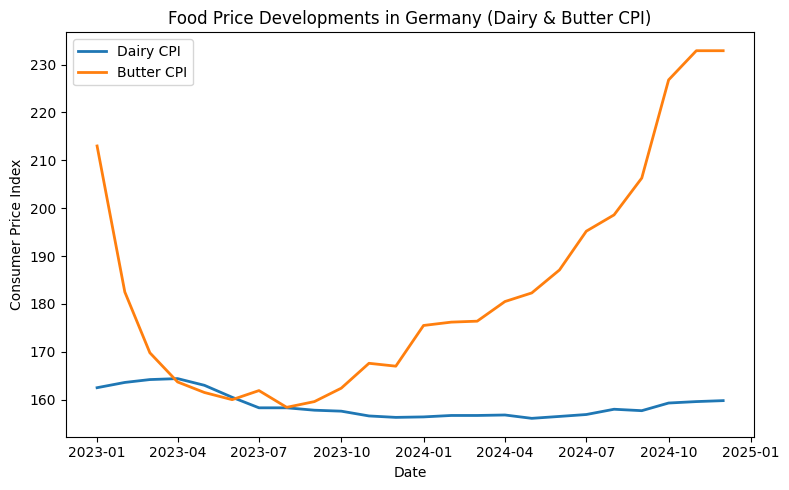

In [43]:
plt.figure(figsize=(8, 5))
plt.plot(dairy["date"], dairy["dairy_cpi"], label="Dairy CPI", linewidth=2)
plt.plot(butter["date"], butter["butter_cpi"], label="Butter CPI", linewidth=2)
plt.title("Food Price Developments in Germany (Dairy & Butter CPI)")
plt.xlabel("Date")
plt.ylabel("Consumer Price Index")
plt.legend()
plt.tight_layout()
plt.show()

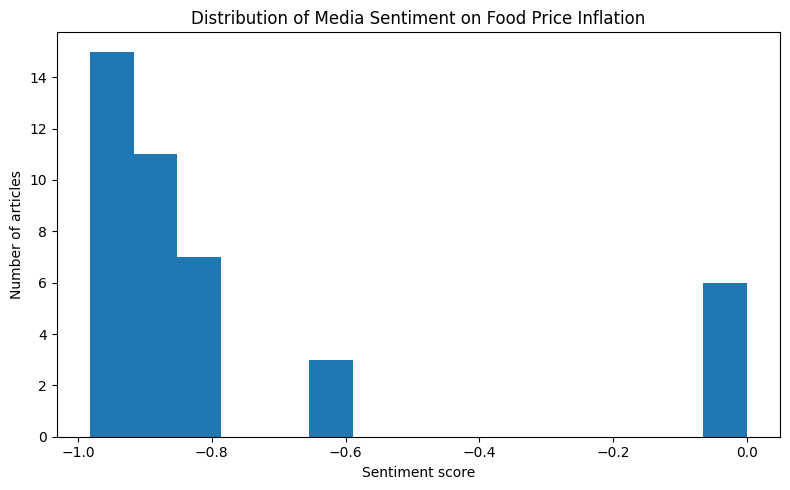

In [44]:
plt.figure(figsize=(8, 5))
plt.hist(news_filtered["sentiment"], bins=15)
plt.title("Distribution of Media Sentiment on Food Price Inflation")
plt.xlabel("Sentiment score")
plt.ylabel("Number of articles")
plt.tight_layout()
plt.show()

## Limitations

A key limitation of this analysis is the mismatch in time coverage between the datasets.  
The CPI data covers food price developments in Germany from 2023 to 2024, while the available news data mainly covers early 2026.

Because of this mismatch, the notebook does not allow for a direct comparison between sentiment and price developments due to the lack of overlapping time periods. Instead, it compares food price developments and media discourse as related but separate indicators.

In addition, the sentiment analysis is based on VADER, which is a general-purpose lexicon-based method and may not fully capture the tone of economic reporting.

In [45]:
import pandas as pd

# =========================
# 1. SENTIMENT DATEN
# =========================

sentiment_export = news_filtered[["sentiment"]].copy()

sentiment_export["type"] = "sentiment"
sentiment_export["date"] = pd.NaT
sentiment_export["dairy_cpi"] = pd.NA
sentiment_export["butter_cpi"] = pd.NA

# Reihenfolge der Spalten
sentiment_export = sentiment_export[
    ["type", "date", "sentiment", "dairy_cpi", "butter_cpi"]
]

# =========================
# 2. PREIS DATEN
# =========================

price_export = dairy[["date", "dairy_cpi"]].copy()

price_export = price_export.merge(
    butter[["date", "butter_cpi"]],
    on="date",
    how="left"
)

price_export["type"] = "prices"
price_export["sentiment"] = pd.NA

# gleiche Spaltenstruktur
price_export = price_export[
    ["type", "date", "sentiment", "dairy_cpi", "butter_cpi"]
]


# =========================
# 3. ZUSAMMENFÜGEN
# =========================

rq6_export_df = pd.concat(
    [sentiment_export, price_export],
    ignore_index=True
)

# anschauen
rq6_export_df.head()

rq6_export_df.to_csv("../../website/data/rq6_data.csv", index=False)

/var/folders/kw/zc7qtxtd0j5dyfl27njttk200000gn/T/ipykernel_74360/3918660467.py:45: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  rq6_export_df = pd.concat(
